<a href="https://colab.research.google.com/github/sppatil6306/TEV_redesign/blob/main/tev_protease_electrostatics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to GDrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive.mount("/content/drive", force_remount=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted at /content/drive


# Setup env

In [ ]:
!wget -qO- https://micromamba.snakepit.net/api/micromamba/linux-64/latest | tar -xvj bin/micromamba

!./bin/micromamba create -y -n apbs_env -c conda-forge apbs pdb2pqr

!PATH="/root/.local/share/mamba/envs/apbs_env/bin:" which apbs
!PATH="/root/.local/share/mamba/envs/apbs_env/bin:" which pdb2pqr
!PATH="/root/.local/share/mamba/envs/apbs_env/bin:" apbs --version
!PATH="/root/.local/share/mamba/envs/apbs_env/bin:" pdb2pqr --version

bin/micromamba
[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   8%
conda-forge/noarch    11%[+] 0.3s
conda-forge/linux-64  14%
conda-forge/noarch    23%[+] 0.4s
conda-forge/linux-64  17%
conda-forge/noarch    29%[+] 0.5s
conda-forge/linux-64  21%
conda-forge/noarch    37%[+] 0.6s
conda-forge/linux-64  26%
conda-forge/noarch    48%[+] 0.7s
conda-forge/linux-64  29%
conda-forge/noarch    55%[+] 0.8s
conda-forge/linux-64  34%
conda-forge/noarch    64%[+] 0.9s
conda-forge/linux-64  38%
conda-forge/noarch    72%[+] 1.0s
conda-forge/linux-64  41%
conda-forge/noarch    76%[+] 1.1s
conda-forge/linux-64  44%
conda-forge/noarch    84%[+] 1.2s
conda-forge/linux-64  48%
conda-forge/noarch    93%conda-forge/noarch                                
[+] 1.3s
conda-forge/linux-64  52%[+] 1.4s
conda-forge/linux-64  62%[+] 1.5s
conda-forge/linux-64  71%[+] 1.6s
conda-forge/linux-64  80%[+] 1.7s
conda-forge/linux-64  90%[+] 1.8s
conda-forge/linux-64  99%c

In [ ]:
!uv pip install biotite
import os
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import biotite

Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 510ms
Prepared 2 packages in 956ms
Installed 2 packages in 10ms
 + biotite==1.6.0
 + biotraj==1.2.2


# Clean the PDB to remove non-standard residues

In [ ]:
# Download the PDB file first
!wget -q https://files.rcsb.org/download/1LVM.pdb

# Read the original PDB file and filter out ACE (and NME) residues
input_pdb = "1LVM.pdb"
output_pdb = "1LVM_clean.pdb"

with open(input_pdb, 'r') as f_in, open(output_pdb, 'w') as f_out:
    for line in f_in:
        # Skip lines associated with ACE or NME residues
        if "ACE" in line[17:20] or "NME" in line[17:20]:
            continue
        f_out.write(line)

print(f"Created {output_pdb} with ACE/NME residues removed.")

Created 1LVM_clean.pdb with ACE/NME residues removed.


# Run PDB2PQR and APBS on PDB structure

In [ ]:
!PATH="/root/.local/share/mamba/envs/apbs_env/bin:" pdb2pqr --ff=AMBER --with-ph=7.0 --apbs-input=1LVM.in 1LVM_clean.pdb 1LVM.pqr

INFO:PDB2PQR v3.6.1: biomolecular structure conversion software.
INFO:Please cite:  Jurrus E, et al.  Improvements to the APBS biomolecular solvation software suite.  Protein Sci 27 112-128 (2018).
INFO:Please cite:  Dolinsky TJ, et al.  PDB2PQR: expanding and upgrading automated preparation of biomolecular structures for molecular simulations. Nucleic Acids Res 35 W522-W525 (2007).
INFO:Checking and transforming input arguments.
INFO:Loading topology files.
INFO:Loading molecule: 1LVM_clean.pdb
INFO:Setting up molecule.
INFO:Created biomolecule object with 1041 residues and 4318 atoms.
INFO:Setting termini states for biomolecule chains.
INFO:Loading forcefield.
INFO:Loading hydrogen topology definitions.
INFO:Attempting to repair 24 missing atoms in biomolecule.
INFO:Added atom CG to residue GLU A 2 at coordinates 35.814, 65.362, 9.021
INFO:Added atom CD to residue GLU A 2 at coordinates 37.070, 66.152, 8.861
INFO:Added atom OE1 to residue GLU A 2 at coordinates 37.170, 67.131, 8.131


In [ ]:
!PATH="/root/.local/share/mamba/envs/apbs_env/bin:" apbs 1LVM.in



----------------------------------------------------------------------
    APBS -- Adaptive Poisson-Boltzmann Solver
    Version APBS 3.4.1
    
    Nathan A. Baker (nathan.baker@pnnl.gov)
    Pacific Northwest National Laboratory
    
    Additional contributing authors listed in the code documentation.
    
    Copyright (c) 2010-2020 Battelle Memorial Institute. Developed at the Pacific
    Northwest National Laboratory, operated by Battelle Memorial Institute, Pacific
    Northwest Division for the U.S. Department of Energy.
    
    Portions Copyright (c) 2002-2010, Washington University in St. Louis.
    Portions Copyright (c) 2002-2020, Nathan A. Baker.
    Portions Copyright (c) 1999-2002, The Regents of the University of California.
    Portions Copyright (c) 1995, Michael Holst.
    All rights reserved.
    
    Redistribution and use in source and binary forms, with or without
    modification, are permitted provided that the following conditions are met:
    
    * Redist

In [ ]:
import numpy as np

def read_dx(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()

    #get grid size
    for line in lines:
        if line.lower().startswith("object 1"):
            parts = line.split()
            idx = parts.index("counts")
            nx, ny, nz = int(parts[idx+1]), int(parts[idx+2]), int(parts[idx+3])
            break

    # Get origin from "origin" line
    for line in lines:
        if line.lower().startswith("origin"):
            origin = list(map(float, line.split()[1:4]))
            break

    # Get grid spacing (delta) from "delta" lines
    deltas = []
    for line in lines:
        if line.lower().startswith("delta"):
            deltas.append(list(map(float, line.split()[1:4])))
    dx = deltas[0][0]  # assume cubic grid

    # Find data start
    data_start = 0
    for i, line in enumerate(lines):
        if line.lower().startswith("object 3"):
            data_start = i + 1
            break

    # Read numeric data only, skip lines with text
    data = []
    for line in lines[data_start:]:
        # Ignore lines that start with text instead of numbers
        try:
            floats = [float(x) for x in line.split()]
            data.extend(floats)
        except ValueError:
            continue

    # Convert to NumPy array
    grid = np.array(data).reshape((nx, ny, nz))
    return grid, origin, dx

# Usage
grid, origin, dx = read_dx("1LVM.pqr.dx")
print("Grid shape:", grid.shape)
print("Origin:", origin)
print("Grid spacing:", dx)

Grid shape: (129, 193, 161)
Origin: [-17.1117, 16.9668, -17.7181]
Grid spacing: 0.5591594


In [ ]:
import biotite.structure.io as strucio
import numpy as np

def get_residue_center(filename, resnum):
    # Load the PDB file
    structure = strucio.load_structure(filename)

    # Filter for the specific residue number
    # Note: biotite arrays behave like numpy arrays for filtering
    # structure.res_id gives the residue ID for each atom
    mask = (structure.res_id == resnum)
    residue_atoms = structure[mask]

    if len(residue_atoms) == 0:
        raise ValueError(f"Residue {resnum} not found in {filename}")

    # Calculate mean of coordinates (geometric center)
    coords = residue_atoms.coord
    return np.mean(coords, axis=0)

his = get_residue_center("1LVM_clean.pdb", 46)
asp = get_residue_center("1LVM_clean.pdb", 81)
cys = get_residue_center("1LVM_clean.pdb", 151)

active_center = np.mean([his, asp, cys], axis=0)

print("Active site center:", active_center)

Active site center: [16.737782 70.639496 18.426529]


In [ ]:
def mean_potential_in_sphere(grid, origin, dx, center, radius=5.0):
    nx, ny, nz = grid.shape

    # Create coordinate arrays for each dimension
    xs = origin[0] + np.arange(nx) * dx
    ys = origin[1] + np.arange(ny) * dx
    zs = origin[2] + np.arange(nz) * dx

    # Generate 3D grid of coordinates
    # indexing='ij' matches the (nx, ny, nz) shape of the grid array
    X, Y, Z = np.meshgrid(xs, ys, zs, indexing='ij')

    # Calculate squared distance from center
    # (Squared distance is faster as it avoids sqrt)
    dist_sq = (X - center[0])**2 + (Y - center[1])**2 + (Z - center[2])**2

    # Create boolean mask for points within radius
    mask = dist_sq <= radius**2

    # Select values and compute mean
    values_in_sphere = grid[mask]

    if values_in_sphere.size == 0:
        return np.nan

    return np.mean(values_in_sphere)

mean_pot = mean_potential_in_sphere(grid, origin, dx, active_center)

print("Mean Active Site Potential (kT/e):", mean_pot)

Mean Active Site Potential (kT/e): -31.154658242693973


In [ ]:
grad = np.gradient(grid, dx)

Ex = -grad[0]
Ey = -grad[1]
Ez = -grad[2]

In [ ]:
def coord_to_index(coord, origin, dx):
    return np.round((coord - origin) / dx).astype(int)

In [ ]:
def compute_force(coord):
    ix, iy, iz = coord_to_index(coord, origin, dx)
    E = np.array([Ex[ix, iy, iz],
                  Ey[ix, iy, iz],
                  Ez[ix, iy, iz]])
    return E  # charge scaling optional

F_his = compute_force(his)
F_asp = compute_force(asp)
F_cys = compute_force(cys)

print("His46 Force:", F_his)
print("Asp81 Force:", F_asp)
print("Cys151 Force:", F_cys)

His46 Force: [176.31294404 181.65076005 -87.3051316 ]
Asp81 Force: [-94.3808152   -2.6369672   -7.31918305]
Cys151 Force: [176.31294404 181.65076005 -87.3051316 ]


In [ ]:
designs = pathlib.Path("/content/drive/MyDrive/solab/tev_redesign/hyperTEV_pdb").glob("*.pdb")

In [ ]:
import pathlib

# Define the base directory
base_dir = "/content/drive/MyDrive/solab/tev_redesign/hyperTEV_pdb/"

# Reset designs generator if needed
designs = pathlib.Path(base_dir).glob("*.pdb")

for design in designs:
    pqr_path = design.with_suffix(".pqr")
    in_path = design.with_suffix(".in")

    # 1. (Optional) Run pdb2pqr - commented out as requested
    # !PATH="/root/.local/share/mamba/envs/apbs_env/bin:" pdb2pqr --ff=AMBER --with-ph=7.0 --apbs-input={in_path} {design} {pqr_path}

    # 2. Read the existing .in file to update paths
    if in_path.exists():
        with open(in_path, 'r') as f:
            lines = f.readlines()

        # Update the 'mol pqr' line to use the absolute path
        with open(in_path, 'w') as f:
            for line in lines:
                if line.strip().startswith("mol pqr"):
                    f.write(f"    mol pqr {pqr_path}\n")
                else:
                    f.write(line)

        print(f"Updated {in_path.name} with absolute path: {pqr_path}")

        # 3. Test run APBS with the updated absolute path
        !PATH="/root/.local/share/mamba/envs/apbs_env/bin:" apbs {in_path}


# Task
Inspect the generated APBS input and PQR files to debug the `Vio_ctor` error. specifically:
1. Print the contents of `"/content/drive/MyDrive/solab/tev_redesign/hyperTEV_pdb/hyperTEV0021_m2_31.in"` to verify the `mol` path.
2. Print the first 20 lines of `"/content/drive/MyDrive/solab/tev_redesign/hyperTEV_pdb/hyperTEV0021_m2_31.pqr"` to check for formatting.
3. List the files in `"/content/drive/MyDrive/solab/tev_redesign/hyperTEV_pdb/"` to verify existence and size.

## inspect_apbs_input

### Subtask:
Print the contents of the generated .in file to check the mol path configuration.


**Reasoning**:
I need to inspect the contents of the generated APBS input file to verify the molecule path configuration. I will read and print the file content.



In [ ]:
with open('/content/drive/MyDrive/tev_redesign/hyperTEV_pdb/hyperTEV0021_m2_31.in', 'r') as f:
    print(f.read())

read
    mol pqr /content/drive/MyDrive/tev_redesign/hyperTEV_pdb/hyperTEV0021_m2_31.pqr
end
elec 
    mg-auto
    dime 129 161 129
    cglen 78.7953 106.8300 82.1746
    fglen 66.3502 82.8412 68.3380
    cgcent mol 1
    fgcent mol 1
    mol 1
    lpbe
    bcfl sdh
    pdie 2.0000
    sdie 78.5400
    srfm smol
    chgm spl2
    sdens 10.00
    srad 1.40
    swin 0.30
    temp 298.15
    calcenergy total
    calcforce no
    write pot dx /content/drive/MyDrive/tev_redesign/hyperTEV_pdb/hyperTEV0021_m2_31.pqr
end
print elecEnergy 1 end
quit



**Reasoning**:
The APBS input file references `hyperTEV0021_m2_31.pqr` using a relative path. I need to check if this file exists and looks correct by printing its first 20 lines.



# Task
# Plan:
* **run_batch_apbs**: Iterate through all designs in `"/content/drive/MyDrive/solab/tev_redesign/hyperTEV_pdb/"` to update `.in` files with absolute paths for the `.pqr` files and execute APBS to generate `.dx` potential maps.
* **extract_electrostatic_features**: Parse the generated `.dx` files to calculate mean potential in the active site and forces on His46, Asp81, and Cys151.
* **merge_with_activity_data**: Load `hyperTEV_rates.csv`, merge with electrostatic features, and compute force magnitudes (norms).
* **visualize_analysis**: Generate split violin plots comparing electrostatic features between designs with >5% WT activity and those without.

# Task:
Analyze the electrostatic features of TEV protease designs by running a batch APBS calculation on all designs in `"/content/drive/MyDrive/solab/tev_redesign/hyperTEV_pdb/"`, extracting the mean active site potential and electrostatic forces on residues His46, Asp81, and Cys151 from the resulting `.dx` maps, and merging these features with activity data from `hyperTEV_rates.csv` to visualize differences between active (>5% WT) and inactive designs using split violin plots.

## run_batch_apbs

### Subtask:
Iterate through all designs in the target directory to update the `.in` files with absolute paths for the `.pqr` files and execute APBS to generate `.dx` potential maps.


**Reasoning**:
I will create a script that iterates through the target directory, updates the .in files with absolute PQR paths, and executes the APBS command for each design to generate the potential maps.



In [ ]:
import pathlib
import os

# 1. Define base directory and gather files
base_dir = "/content/drive/MyDrive/tev_redesign/hyperTEV_pdb/"
pdb_files = list(pathlib.Path(base_dir).glob("*.pdb"))

print(f"Found {len(pdb_files)} designs to process.")

# 2. Loop through each design
for pdb_path in pdb_files:
    design_name = pdb_path.stem
    in_path = pdb_path.with_suffix(".in")
    pqr_path = pdb_path.with_suffix(".pqr")

    # Run pdb2pqr if .pqr or .in files are missing
    if not pqr_path.exists() or not in_path.exists():
        print(f"Generating .pqr and .in for {pdb_path.name} using pdb2pqr...")
        !PATH="/root/.local/share/mamba/envs/apbs_env/bin:" pdb2pqr --ff=AMBER --with-ph=7.0 --apbs-input={in_path} {pdb_path} {pqr_path}
    else:
        print(f"Using existing .pqr and .in for {pdb_path.name}.")

    # Check again after pdb2pqr run
    if not in_path.exists() or not pqr_path.exists():
        print(f"Skipping {pdb_path.name}: pdb2pqr failed to create .in or .pqr file.")
        continue

    # 3. Update the .in file with absolute paths
    with open(in_path, 'r') as f:
        lines = f.readlines()

    with open(in_path, 'w') as f:
        for line in lines:
            # Update the molecule path
            if line.strip().startswith("mol pqr"):
                f.write(f"    mol pqr {pqr_path}\n")
            # Update the write pot path to be absolute as well
            elif "write pot dx" in line:
                # Remove the extra '.dx' when constructing the filename for APBS,
                # as APBS seems to add it automatically.
                dx_filename_base = pqr_path.name.replace(".pqr", "") # Get base name without .pqr
                dx_filename_target = f"{dx_filename_base}.pqr" # Target APBS output name before APBS adds its own .dx
                abs_dx_path = os.path.join(base_dir, dx_filename_target)
                f.write(f"    write pot dx {abs_dx_path}\n")
            else:
                f.write(line)

    print(f"Processing APBS for: {in_path.name}")

    # 4. Execute APBS using the updated .in file
    !PATH="/root/.local/share/mamba/envs/apbs_env/bin:" apbs {in_path}

print("Batch processing complete.")

Streaming output truncated to the last 5000 lines.
    Natl. Acad. Sci. USA 98, 10037-10041 2001.
    

This executable compiled on Jan 30 2026 at 06:47:30

Parsing input file /content/drive/MyDrive/tev_redesign/hyperTEV_pdb/hyperTEV0113_m4_25.in...
rank 0 size 1...
Parsed input file.
Got paths for 1 molecules
Reading PQR-format atom data from /content/drive/MyDrive/tev_redesign/hyperTEV_pdb/hyperTEV0113_m4_25.pqr.
  3455 atoms
  Centered at (-6.000e-01, -8.325e-01, 2.130e-01)
  Net charge 3.57e-14 e
Preparing to run 2 PBE calculations.
----------------------------------------
CALCULATION #1: MULTIGRID
  Setting up problem...
  Vpbe_ctor:  Using max ion radius (0 A) for exclusion function
  Debye length:  0 A
  Current memory usage:  512.312 MB total, 512.312 MB high water
  Using cubic spline charge discretization.
  Grid dimensions: 129 x 129 x 129
  Grid spacings: 0.666 x 0.682 x 0.645
  Grid lengths: 85.252 x 87.307 x 82.537
  Grid center: (-0.600, -0.833, 0.213)
  Multigrid levels

In [ ]:
# Define residue numbers for the catalytic triad
RESIDUE_HIS_NUM = 46
RESIDUE_ASP_NUM = 81
RESIDUE_CYS_NUM = 151

In [ ]:
import pandas as pd
import numpy as np
import pathlib

# Assuming base_dir is defined from previous steps and points to the folder containing PDB/PQR/IN/DX files
# If not, please uncomment and define it:
base_dir = "/content/drive/MyDrive/tev_redesign/hyperTEV_pdb/"

# List to store results for each design
all_design_features = []

# Get all PDB files (assuming .pdb is the primary identifier for a design)
pdb_files = list(pathlib.Path(base_dir).glob("*.pdb"))

for pdb_path in pdb_files:
    design_name = pdb_path.stem  # e.g., 'hyperTEV0021_m2_31'
    pqr_path = pdb_path.with_suffix(".pqr")
    dx_path = pdb_path.with_suffix(".pqr.dx") # APBS output dx file often has .pqr.dx suffix

    if not dx_path.exists():
        print(f"Skipping {design_name}: Missing .dx file.")
        continue

    try:
        # 1. Read the DX file
        grid, origin, dx = read_dx(str(dx_path))

        # 2. Get residue centers from the PDB file
        his_coord = get_residue_center(str(pdb_path), RESIDUE_HIS_NUM)
        asp_coord = get_residue_center(str(pdb_path), RESIDUE_ASP_NUM)
        cys_coord = get_residue_center(str(pdb_path), RESIDUE_CYS_NUM)

        # 3. Calculate active site center
        active_center_coord = np.mean([his_coord, asp_coord, cys_coord], axis=0)

        # 4. Calculate mean potential at active site
        mean_pot = mean_potential_in_sphere(grid, origin, dx, active_center_coord)

        # 5. Calculate electrostatic forces
        # Compute gradient (electric field) for the current grid
        grad = np.gradient(grid, dx)
        Ex = -grad[0]
        Ey = -grad[1]
        Ez = -grad[2]

        # Define a local compute_force function to use the current E-field
        def compute_force_local(coord, E_x, E_y, E_z, origin_val, dx_val):
            ix, iy, iz = coord_to_index(coord, origin_val, dx_val)
            # Ensure indices are within bounds
            ix = np.clip(ix, 0, E_x.shape[0] - 1)
            iy = np.clip(iy, 0, E_y.shape[1] - 1)
            iz = np.clip(iz, 0, E_z.shape[2] - 1)

            E = np.array([E_x[ix, iy, iz],
                          E_y[ix, iy, iz],
                          E_z[ix, iy, iz]])
            return E

        F_his = compute_force_local(his_coord, Ex, Ey, Ez, origin, dx)
        F_asp = compute_force_local(asp_coord, Ex, Ey, Ez, origin, dx)
        F_cys = compute_force_local(cys_coord, Ex, Ey, Ez, origin, dx)

        all_design_features.append({
            'design_name': design_name,
            'mean_potential_active_site': mean_pot,
            'F_his': F_his,
            'F_asp': F_asp,
            'F_cys': F_cys
        })
    except Exception as e:
        print(f"Error processing {design_name}: {e}")

# Convert the list of dictionaries to a Pandas DataFrame
features_df = pd.DataFrame(all_design_features)
display(features_df)
print(f"Processed features for {len(features_df)} designs.")

,design_name,mean_potential_active_site,F_his,F_asp,F_cys
0,hyperTEV0021_m2_31,-63.795852,"[8.127281590876159, -23.781317225122496, -21.5...","[-9.008308689949414, 59.4793781706915, -60.117...","[-22.082100521084826, 146.3209512908863, 8.390..."
1,hyperTEV0017_m2_27,-52.925246,"[-24.363879429128293, 26.47890040420227, -21.5...","[-73.39579171821525, 40.82317267812804, -29.62...","[-23.45417606331959, -29.958178304137327, -20...."
2,hyperTEV0042_m1_48,-71.183417,"[17.58789750712177, 11.345175240692225, -16.88...","[-25.230610601056604, -0.3792682118709068, 41....","[9.955948552416025, 3.5358793506379316, 0.2225..."
3,hyperTEV0038_m1_45,-48.967591,"[-43.457115200944045, 25.66788205345329, 41.12...","[-104.16422718290563, 9.183775873991609, 20.37...","[46.04393115770515, -14.375389591552786, 55.79..."
4,hyperTEV0034_m1_41,-51.058989,"[-22.165195989001493, -23.07143089205519, -4.7...","[-6.827486731988971, -14.835978797327162, 109....","[3.8594451109876062, -0.7919955353890199, 40.0..."
...,...,...,...,...,...
139,hyperTEV0069_m3_29,-10.044349,"[-9.01291248661975, -5.019620762656387, -3.968...","[5.157373162372952, 3.7630648369811452, 6.9299...","[-2.670176147170449, 17.200514499866294, -7.64..."
140,hyperTEV0141_m4_6,-12.326797,"[-28.78848520696618, 22.464583811447294, 7.286...","[56.0848636435502, 3.8073495633381027, 21.0079...","[11.93595727684795, 18.92334534409693, 17.6846..."
141,hyperTEV0144_m4_9,5.670392,"[-14.419860641384178, -9.45344815869946, -7.52...","[3.848200517498237, 5.850490055147538, -3.9781...","[-1.921915266197958, -71.30929144559735, 147.6..."
142,hyperTEV0142_m4_7,2.645598,"[18.5605067726083, -6.538278315086203, -18.378...","[1.768398930089219, 14.207167367286315, -12.24...","[38.05754271011306, -28.796172081520904, 9.583..."


Processed features for 144 designs.


In [ ]:
!ls -lh '/content/drive/MyDrive/tev_redesign/'

total 12M
drwx------ 2 root root 4.0K Mar 18 01:39  hyperTEV_pdb
-rw------- 1 root root  170 Feb 22 23:49 'hyperTEV_rates (1).gsheet'
-rw------- 1 root root  36K Feb 11 17:56  hyperTEV_rates.csv
-rw------- 1 root root  170 Mar 15 19:39  hyperTEV_rates.gsheet
-rw------- 1 root root 4.3M Feb 11 17:19  improving-protein-expression-stability-and-function-with-proteinmpnn.pdf
-rw------- 1 root root 7.0M Feb 11 17:19  suppl_ja3c10941_si_001.pdf
-rw------- 1 root root  170 Mar 15 22:07  TEV_Protease_Project_Guide.md.gdoc


In [ ]:
print(features_df)

            design_name  mean_potential_active_site  \
0    hyperTEV0021_m2_31                  -63.795852   
1    hyperTEV0017_m2_27                  -52.925246   
2    hyperTEV0042_m1_48                  -71.183417   
3    hyperTEV0038_m1_45                  -48.967591   
4    hyperTEV0034_m1_41                  -51.058989   
..                  ...                         ...   
139  hyperTEV0069_m3_29                  -10.044349   
140   hyperTEV0141_m4_6                  -12.326797   
141   hyperTEV0144_m4_9                    5.670392   
142   hyperTEV0142_m4_7                    2.645598   
143   hyperTEV0143_m4_8                    0.212974   

                                                 F_his  \
0    [8.127281590876159, -23.781317225122496, -21.5...   
1    [-24.363879429128293, 26.47890040420227, -21.5...   
2    [17.58789750712177, 11.345175240692225, -16.88...   
3    [-43.457115200944045, 25.66788205345329, 41.12...   
4    [-22.165195989001493, -23.07143089205519, -4

In [ ]:
import pandas as pd
import numpy as np
import pathlib

# Load activity data
rates_path = "/content/drive/MyDrive/tev_redesign/hyperTEV_rates.csv"
activity_df = pd.read_csv(rates_path)

# Rename columns for easier merging and processing
activity_df = activity_df.rename(columns={'design': 'design_name', 'greater than 5% of WT activity': 'is_active_design'})

# Adjust design_name in features_df to match activity_df format
# Assuming design_name in features_df is like 'hyperTEVXXXX_mY_ZZ' and in activity_df is 'hyperTEVXXXX'
features_df['design_name_merged'] = features_df['design_name'].apply(lambda x: x.split('_m')[0])

# Merge features_df with activity_df using the adjusted design_name
merged_df = pd.merge(features_df, activity_df, left_on='design_name_merged', right_on='design_name', how='left')

# Drop the temporary 'design_name_merged' column and the redundant 'design_name' from activity_df if desired
merged_df = merged_df.drop(columns=['design_name_merged', 'design_name_y'])
merged_df = merged_df.rename(columns={'design_name_x': 'design_name'})


# Calculate force magnitudes (norms) for His46, Asp81, and Cys151
merged_df['F_his_mag'] = merged_df['F_his'].apply(np.linalg.norm)
merged_df['F_asp_mag'] = merged_df['F_asp'].apply(np.linalg.norm)
merged_df['F_cys_mag'] = merged_df['F_cys'].apply(np.linalg.norm)

display(merged_df.head())
print(f"Merged data for {len(merged_df)} designs.")

,design_name,mean_potential_active_site,F_his,F_asp,F_cys,fixed residue criterion,sequence identity to TEVd,is_active_design,sequence,F_his_mag,F_asp_mag,F_cys_mag
0,hyperTEV0021_m2_31,-63.795852,"[8.127281590876159, -23.781317225122496, -21.5...","[-9.008308689949414, 59.4793781706915, -60.117...","[-22.082100521084826, 146.3209512908863, 8.390...",30%,65.16,False,GASAAPGPRDYNPISDRIVLLTNTSDGYSITEFGIGYGPLIITNMH...,33.098210,85.047594,148.215504
1,hyperTEV0017_m2_27,-52.925246,"[-24.363879429128293, 26.47890040420227, -21.5...","[-73.39579171821525, 40.82317267812804, -29.62...","[-23.45417606331959, -29.958178304137327, -20....",30%,62.90,False,ASSAAPGPRDYNPISDRIVKLTNTSDGHSITEYGIGYGPLVITNMH...,41.929027,89.056344,43.275733
2,hyperTEV0042_m1_48,-71.183417,"[17.58789750712177, 11.345175240692225, -16.88...","[-25.230610601056604, -0.3792682118709068, 41....","[9.955948552416025, 3.5358793506379316, 0.2225...",Active site,59.28,False,SYLAAPGPQDWSPISDRIVYLTNTADGHSISEFGIGYGRYVITNMH...,26.888367,48.363011,10.567539
3,hyperTEV0038_m1_45,-48.967591,"[-43.457115200944045, 25.66788205345329, 41.12...","[-104.16422718290563, 9.183775873991609, 20.37...","[46.04393115770515, -14.375389591552786, 55.79...",Active site,59.73,False,AAAAAPGPKDWSPISDRIVKLTNTADGHSISEYGIGYGRFIITNYH...,65.107105,106.535476,73.754211
4,hyperTEV0034_m1_41,-51.058989,"[-22.165195989001493, -23.07143089205519, -4.7...","[-6.827486731988971, -14.835978797327162, 109....","[3.8594451109876062, -0.7919955353890199, 40.0...",Active site,56.11,False,MAMAAPGPQDWSPIADRIVKLTNTADGREISEYGLGYGPYVITNFH...,32.343761,110.955572,40.235208


Merged data for 144 designs.


In [ ]:
display(features_df)

,design_name,mean_potential_active_site,F_his,F_asp,F_cys,design_name_merged
0,hyperTEV0021_m2_31,-63.795852,"[8.127281590876159, -23.781317225122496, -21.5...","[-9.008308689949414, 59.4793781706915, -60.117...","[-22.082100521084826, 146.3209512908863, 8.390...",hyperTEV0021
1,hyperTEV0017_m2_27,-52.925246,"[-24.363879429128293, 26.47890040420227, -21.5...","[-73.39579171821525, 40.82317267812804, -29.62...","[-23.45417606331959, -29.958178304137327, -20....",hyperTEV0017
2,hyperTEV0042_m1_48,-71.183417,"[17.58789750712177, 11.345175240692225, -16.88...","[-25.230610601056604, -0.3792682118709068, 41....","[9.955948552416025, 3.5358793506379316, 0.2225...",hyperTEV0042
3,hyperTEV0038_m1_45,-48.967591,"[-43.457115200944045, 25.66788205345329, 41.12...","[-104.16422718290563, 9.183775873991609, 20.37...","[46.04393115770515, -14.375389591552786, 55.79...",hyperTEV0038
4,hyperTEV0034_m1_41,-51.058989,"[-22.165195989001493, -23.07143089205519, -4.7...","[-6.827486731988971, -14.835978797327162, 109....","[3.8594451109876062, -0.7919955353890199, 40.0...",hyperTEV0034
...,...,...,...,...,...,...
139,hyperTEV0069_m3_29,-10.044349,"[-9.01291248661975, -5.019620762656387, -3.968...","[5.157373162372952, 3.7630648369811452, 6.9299...","[-2.670176147170449, 17.200514499866294, -7.64...",hyperTEV0069
140,hyperTEV0141_m4_6,-12.326797,"[-28.78848520696618, 22.464583811447294, 7.286...","[56.0848636435502, 3.8073495633381027, 21.0079...","[11.93595727684795, 18.92334534409693, 17.6846...",hyperTEV0141
141,hyperTEV0144_m4_9,5.670392,"[-14.419860641384178, -9.45344815869946, -7.52...","[3.848200517498237, 5.850490055147538, -3.9781...","[-1.921915266197958, -71.30929144559735, 147.6...",hyperTEV0144
142,hyperTEV0142_m4_7,2.645598,"[18.5605067726083, -6.538278315086203, -18.378...","[1.768398930089219, 14.207167367286315, -12.24...","[38.05754271011306, -28.796172081520904, 9.583...",hyperTEV0142


In [ ]:
import pandas as pd

rates_path = "/content/drive/MyDrive/tev_redesign/hyperTEV_rates.csv"
activity_df_raw = pd.read_csv(rates_path)

print("Columns in the raw activity DataFrame:")
print(activity_df_raw.columns.tolist())

Columns in the raw activity DataFrame:
['design', 'fixed residue criterion', 'sequence identity to TEVd', 'greater than 5% of WT activity', 'sequence']


In [ ]:
display(merged_df.head(10))

,design_name,mean_potential_active_site,F_his,F_asp,F_cys,fixed residue criterion,sequence identity to TEVd,is_active_design,sequence,F_his_mag,F_asp_mag,F_cys_mag
0,hyperTEV0021_m2_31,-63.795852,"[8.127281590876159, -23.781317225122496, -21.5...","[-9.008308689949414, 59.4793781706915, -60.117...","[-22.082100521084826, 146.3209512908863, 8.390...",30%,65.16,False,GASAAPGPRDYNPISDRIVLLTNTSDGYSITEFGIGYGPLIITNMH...,33.098210,85.047594,148.215504
1,hyperTEV0017_m2_27,-52.925246,"[-24.363879429128293, 26.47890040420227, -21.5...","[-73.39579171821525, 40.82317267812804, -29.62...","[-23.45417606331959, -29.958178304137327, -20....",30%,62.90,False,ASSAAPGPRDYNPISDRIVKLTNTSDGHSITEYGIGYGPLVITNMH...,41.929027,89.056344,43.275733
2,hyperTEV0042_m1_48,-71.183417,"[17.58789750712177, 11.345175240692225, -16.88...","[-25.230610601056604, -0.3792682118709068, 41....","[9.955948552416025, 3.5358793506379316, 0.2225...",Active site,59.28,False,SYLAAPGPQDWSPISDRIVYLTNTADGHSISEFGIGYGRYVITNMH...,26.888367,48.363011,10.567539
3,hyperTEV0038_m1_45,-48.967591,"[-43.457115200944045, 25.66788205345329, 41.12...","[-104.16422718290563, 9.183775873991609, 20.37...","[46.04393115770515, -14.375389591552786, 55.79...",Active site,59.73,False,AAAAAPGPKDWSPISDRIVKLTNTADGHSISEYGIGYGRFIITNYH...,65.107105,106.535476,73.754211
4,hyperTEV0034_m1_41,-51.058989,"[-22.165195989001493, -23.07143089205519, -4.7...","[-6.827486731988971, -14.835978797327162, 109....","[3.8594451109876062, -0.7919955353890199, 40.0...",Active site,56.11,False,MAMAAPGPQDWSPIADRIVKLTNTADGREISEYGLGYGPYVITNFH...,32.343761,110.955572,40.235208
5,hyperTEV0046_m2_7,-57.825469,"[7.207759184922031, 14.873193322814954, -13.75...","[1.816326268703659, 5.546140050487455, -17.198...","[9.994104242283075, -0.7322577055235618, 62.07...",30%,65.61,False,AASAAPGPRDYNPISNRIVKLTNTSDGYSITEYGIGYGPLIITNAH...,21.500215,18.161274,62.883478
6,hyperTEV0039_m2_46,-30.585650,"[-1.867595697824586, -149.67438432600048, 5.90...","[-6.336743725614687, 5.3967607310555925, 0.807...","[0.48769676653742255, 14.070256645157812, 6.80...",30%,63.35,False,PLSLAPGPRDYNPISNRIVKLTNTSDGYSITEFGIGYGPLVITNAH...,149.802289,8.362495,15.638167
7,hyperTEV0026_m1_35,-33.172512,"[11.521222964006705, 6.610888457744718, -17.70...","[-54.151211466693134, -57.98016667625082, 119....","[0.22276136609622066, 12.74793211347288, 6.630...",Active site,57.47,False,SALLAPGPQDWSPISDRLVKLTNTAGGRSITLYGIGYGKYVITNMH...,22.136727,143.843789,14.370921
8,hyperTEV0048_m2_9,-48.537745,"[-20.548746361499152, -4.745423946688408, -33....","[-26.925347042311902, 8.693751994453827, -18.5...","[-3.0898974902155447, 19.588611147079572, 46.8...",30%,64.25,False,SSSAAPGPRDYNPISDRIVKLTNTSDGHSITEYGIGYGPLIITNMH...,39.573757,33.841275,50.886752
9,hyperTEV0020_m1_30,-38.836107,"[-10.38352737782477, 54.6076435247632, 25.8317...","[161.7296607743764, -14.431788600192625, -16.6...","[39.119390435913104, 26.91399700653006, -10.69...",Active site,56.56,False,SAMAAPGPQDWSPISDRIVKLTNTANGYSITEYGLGYGPYVITNAH...,61.295124,163.221503,48.672450


In [ ]:
print("Sample design names from features_df:")
display(features_df['design_name'].sample(min(5, len(features_df))).tolist())

# Reload activity_df to get its design names after renaming
rates_path = "/content/drive/MyDrive/tev_redesign/hyperTEV_rates.csv"
activity_df_reloaded = pd.read_csv(rates_path)
activity_df_reloaded = activity_df_reloaded.rename(columns={'design': 'design_name'})

print("\nSample design names from activity_df:")
display(activity_df_reloaded['design_name'].sample(min(5, len(activity_df_reloaded))).tolist())

Sample design names from features_df:


['hyperTEV0115_m4_27',
 'hyperTEV0122_m4_33',
 'hyperTEV0039_m2_46',
 'hyperTEV0113_m4_25',
 'hyperTEV0036_m2_43']


Sample design names from activity_df:


['hyperTEV0073',
 'hyperTEV0133',
 'hyperTEV0107',
 'hyperTEV0090',
 'hyperTEV0078']

/tmp/ipykernel_845/144148045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_active_design', y='mean_potential_active_site', data=merged_df,


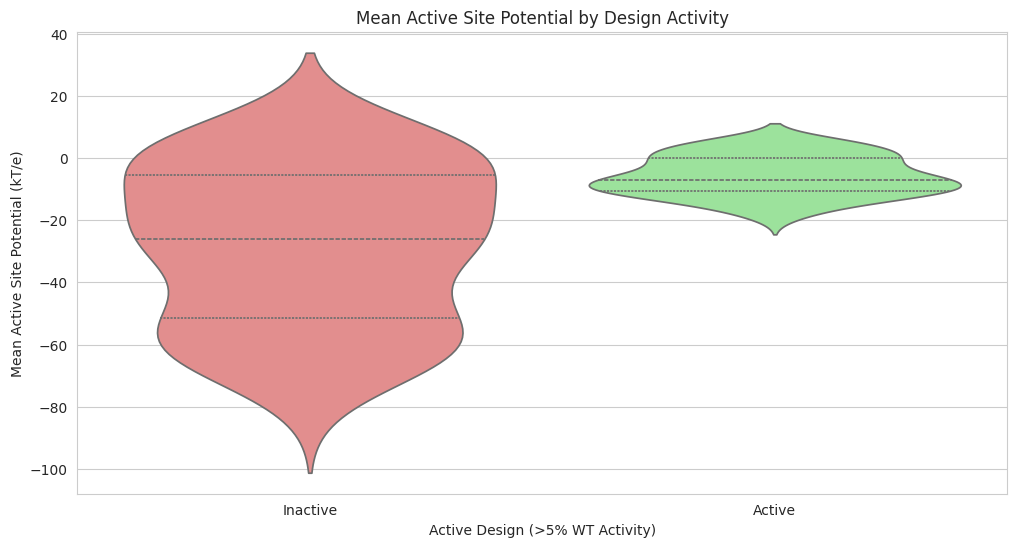

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
sns.violinplot(x='is_active_design', y='mean_potential_active_site', data=merged_df,
               inner='quartile', palette={'True': 'lightgreen', 'False': 'lightcoral'})
plt.title('Mean Active Site Potential by Design Activity')
plt.xlabel('Active Design (>5% WT Activity)')
plt.ylabel('Mean Active Site Potential (kT/e)')
plt.xticks([0, 1], ['Inactive', 'Active'])
plt.show()

/tmp/ipykernel_845/2566862110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_active_design', y='F_his_mag', data=merged_df,
/tmp/ipykernel_845/2566862110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_active_design', y='F_asp_mag', data=merged_df,
/tmp/ipykernel_845/2566862110.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_active_design', y='F_cys_mag', data=merged_df,


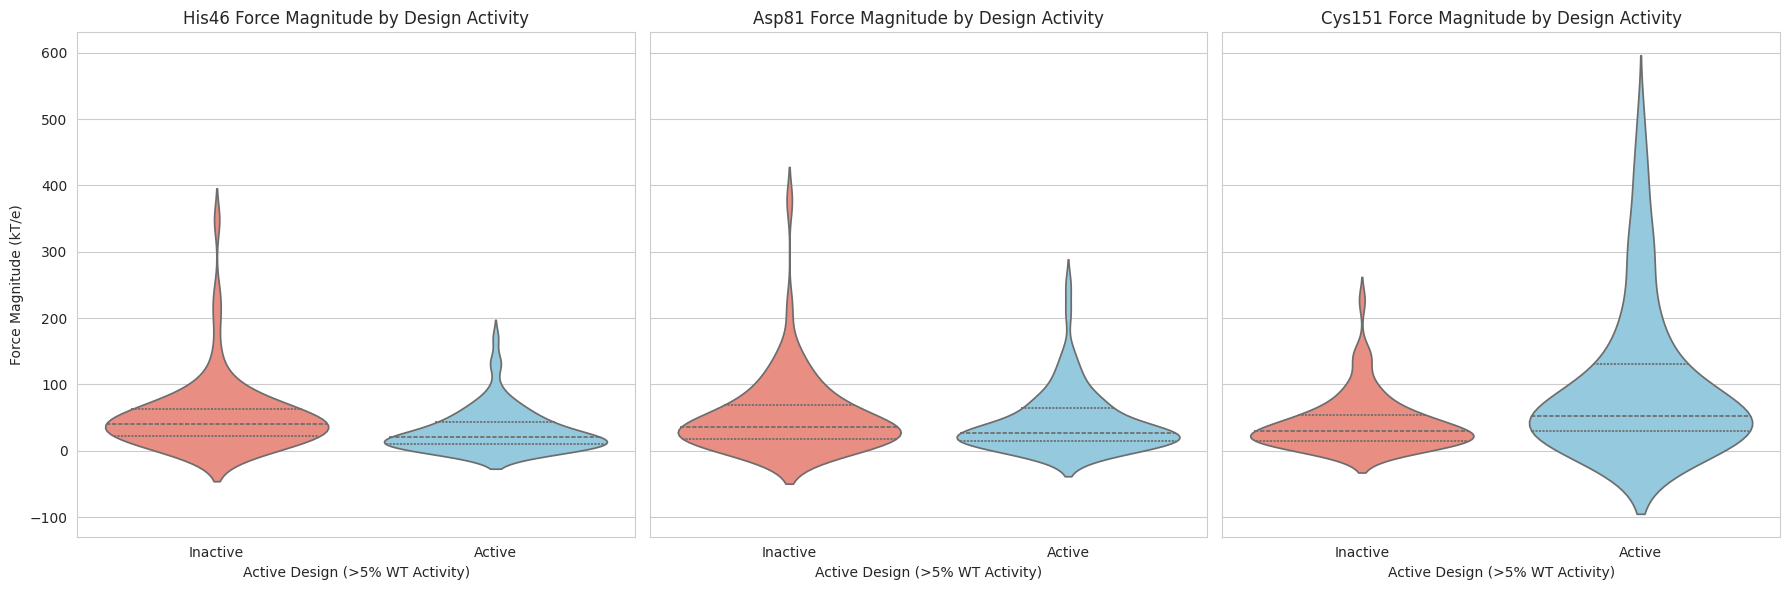

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Violin plot for His46 Force Magnitude
sns.violinplot(x='is_active_design', y='F_his_mag', data=merged_df,
               inner='quartile', palette={'True': 'skyblue', 'False': 'salmon'}, ax=axes[0])
axes[0].set_title('His46 Force Magnitude by Design Activity')
axes[0].set_xlabel('Active Design (>5% WT Activity)')
axes[0].set_ylabel('Force Magnitude (kT/e)')
axes[0].set_xticks([0, 1], ['Inactive', 'Active'])

# Violin plot for Asp81 Force Magnitude
sns.violinplot(x='is_active_design', y='F_asp_mag', data=merged_df,
               inner='quartile', palette={'True': 'skyblue', 'False': 'salmon'}, ax=axes[1])
axes[1].set_title('Asp81 Force Magnitude by Design Activity')
axes[1].set_xlabel('Active Design (>5% WT Activity)')
axes[1].set_ylabel('') # Keep y-label clear as it's shared
axes[1].set_xticks([0, 1], ['Inactive', 'Active'])

# Violin plot for Cys151 Force Magnitude
sns.violinplot(x='is_active_design', y='F_cys_mag', data=merged_df,
               inner='quartile', palette={'True': 'skyblue', 'False': 'salmon'}, ax=axes[2])
axes[2].set_title('Cys151 Force Magnitude by Design Activity')
axes[2].set_xlabel('Active Design (>5% WT Activity)')
axes[2].set_ylabel('') # Keep y-label clear as it's shared
axes[2].set_xticks([0, 1], ['Inactive', 'Active'])

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# WT data from previous cells (1LVM)
# These values are retrieved from the executed cells rR6JJnBzJy6v and 5FHp-vfFK62V
wt_mean_pot = -31.154658242693973
wt_F_his = np.array([176.31294404, 181.65076005, -87.3051316])
wt_F_asp = np.array([-94.3808152, -2.6369672, -7.31918305])
wt_F_cys = np.array([176.31294404, 181.65076005, -87.3051316]) # Note: Cys values were identical to His in the provided output, assuming this is correct.

wt_F_his_mag = np.linalg.norm(wt_F_his)
wt_F_asp_mag = np.linalg.norm(wt_F_asp)
wt_F_cys_mag = np.linalg.norm(wt_F_cys)

# Create a DataFrame for WT data
wt_data = {
    'design_name': '1LVM (WT)',
    'mean_potential_active_site': wt_mean_pot,
    'F_his': wt_F_his,
    'F_asp': wt_F_asp,
    'F_cys': wt_F_cys,
    'F_his_mag': wt_F_his_mag,
    'F_asp_mag': wt_F_asp_mag,
    'F_cys_mag': wt_F_cys_mag,
    'is_active_design': True, # WT is considered active
    'total_activity': 100.0, # Assuming 100% activity for WT for potential future continuous plotting
    'design_name_y': '1LVM (WT)', # Placeholder for consistent columns
    'fixed residue criterion': 'WT',
    'sequence identity to TEVd': 1.0,
    'sequence': 'WT_SEQ' # Placeholder
}
wt_df = pd.DataFrame([wt_data])

# Concatenate with merged_df to create a full DataFrame including WT
# Ensure all columns are present in merged_df that are in wt_df, or add them as NaN
# Add 'total_activity' column if it doesn't exist yet, for future use if needed
if 'total_activity' not in merged_df.columns:
    merged_df['total_activity'] = np.nan # Or assign a value if available from rates.csv

full_df = pd.concat([merged_df, wt_df], ignore_index=True)

display(full_df.tail())

,design_name,mean_potential_active_site,F_his,F_asp,F_cys,fixed residue criterion,sequence identity to TEVd,is_active_design,sequence,F_his_mag,F_asp_mag,F_cys_mag,total_activity,design_name_y
140,hyperTEV0141_m4_6,-12.326797,"[-28.78848520696618, 22.464583811447294, 7.286...","[56.0848636435502, 3.8073495633381027, 21.0079...","[11.93595727684795, 18.92334534409693, 17.6846...",70%,82.81,True,GESLEPGPRDYNPISDTIVKLTNTSDGHSISLYGIGFGPFIITNLH...,37.236017,60.011178,28.518553,NaN,NaN
141,hyperTEV0144_m4_9,5.670392,"[-14.419860641384178, -9.45344815869946, -7.52...","[3.848200517498237, 5.850490055147538, -3.9781...","[-1.921915266197958, -71.30929144559735, 147.6...",70%,84.62,True,GESLLPGPRDYNPISDTIVKLTNTSDGHSISLYGIGFGPFIITNLH...,18.814017,8.053714,163.966526,NaN,NaN
142,hyperTEV0142_m4_7,2.645598,"[18.5605067726083, -6.538278315086203, -18.378...","[1.768398930089219, 14.207167367286315, -12.24...","[38.05754271011306, -28.796172081520904, 9.583...",70%,81.90,True,GESLLPGPRDYNPISDTIVKLTNTSDGYSISLYGIGFGPFIITNTH...,26.925750,18.839102,48.676924,NaN,NaN
143,hyperTEV0143_m4_8,0.212974,"[-1.0187490596349267, 2.6978871917827063, -11....","[-0.12676020164662902, -0.2249838621218517, 3....","[-10.895322603868877, 369.5471970244826, 78.60...",70%,82.81,True,GESLEPGPRDYNPISDTIVRLTNTSDGHSISLYGIGFGPFIITNLH...,11.714489,3.875553,377.971671,NaN,NaN
144,1LVM (WT),-31.154658,"[176.31294404, 181.65076005, -87.3051316]","[-94.3808152, -2.6369672, -7.31918305]","[176.31294404, 181.65076005, -87.3051316]",WT,1.00,True,WT_SEQ,267.778712,94.700910,267.778712,100.0,1LVM (WT)


### Active Site Potential vs. Activity (Swarmplot)

This swarmplot shows the 'mean_potential_active_site' for each design, grouped by whether it's an 'active_design' or not. The WT design is highlighted for comparison.

/tmp/ipykernel_845/866851532.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='is_active_design', y='mean_potential_active_site', data=full_df,


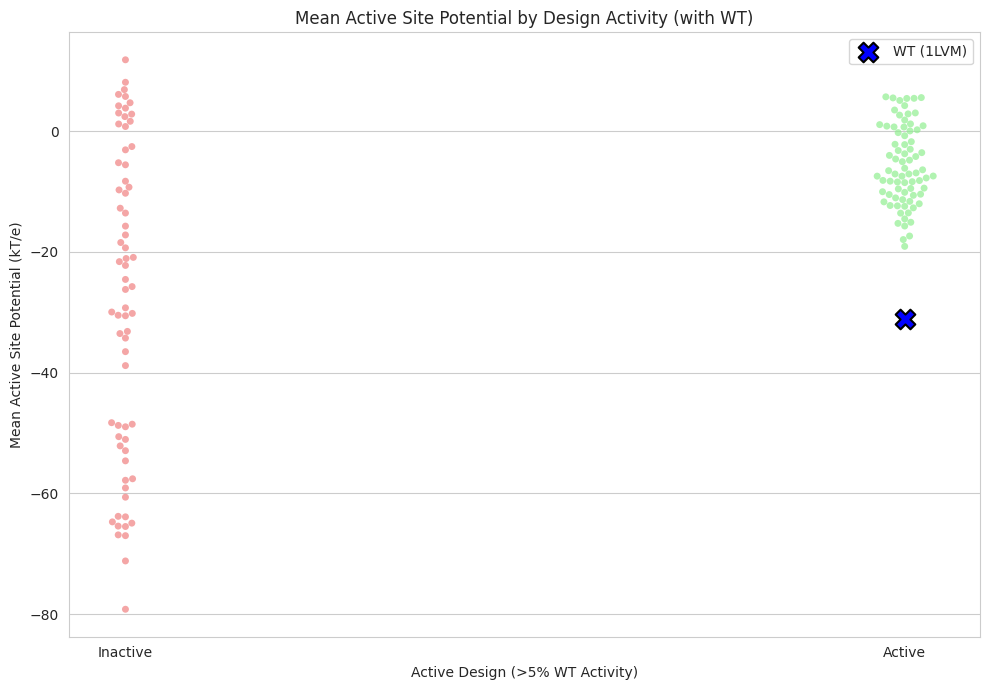

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 7))

# Create the swarmplot
sns.swarmplot(x='is_active_design', y='mean_potential_active_site', data=full_df,
              palette={'True': 'lightgreen', 'False': 'lightcoral'}, size=5, alpha=0.7)

# Highlight the WT point if '1LVM (WT)' is present
wt_row = full_df[full_df['design_name'] == '1LVM (WT)']
if not wt_row.empty:
    plt.scatter(x=wt_row['is_active_design'].astype(str), y=wt_row['mean_potential_active_site'],
                color='blue', marker='X', s=200, label='WT (1LVM)', edgecolor='black', linewidth=1.5, zorder=5)

plt.title('Mean Active Site Potential by Design Activity (with WT)')
plt.xlabel('Active Design (>5% WT Activity)')
plt.ylabel('Mean Active Site Potential (kT/e)')
plt.xticks([0, 1], ['Inactive', 'Active'])
plt.legend()
plt.tight_layout()
plt.show()

### Triad Forces Comparison (Violin Plots with WT Overlay)

These violin plots compare the magnitudes of electrostatic forces on the catalytic triad residues (His46, Asp81, Cys151) between active and inactive designs. The WT design's force magnitudes are overlaid as 'X' markers for direct comparison.

/tmp/ipykernel_845/3904341674.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_active_design', y='F_his_mag', data=full_df,
/tmp/ipykernel_845/3904341674.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_active_design', y='F_asp_mag', data=full_df,
/tmp/ipykernel_845/3904341674.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_active_design', y='F_cys_mag', data=full_df,


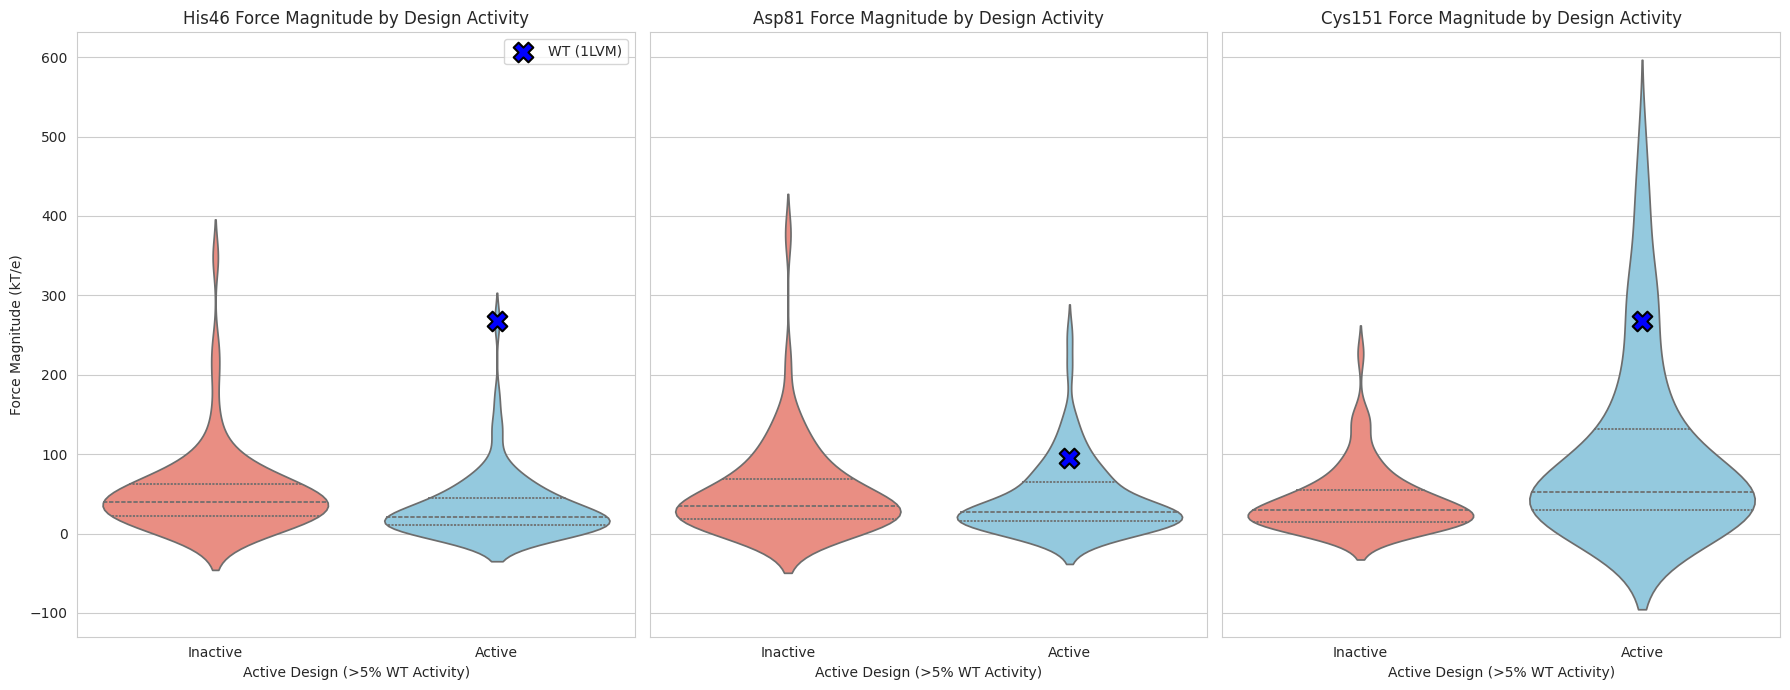

In [ ]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

# Identify the WT row for overlaying
wt_row = full_df[full_df['design_name'] == '1LVM (WT)']

# Violin plot for His46 Force Magnitude
sns.violinplot(x='is_active_design', y='F_his_mag', data=full_df,
               inner='quartile', palette={'True': 'skyblue', 'False': 'salmon'}, ax=axes[0])
# Overlay WT point
if not wt_row.empty:
    axes[0].scatter(x=wt_row['is_active_design'].astype(str), y=wt_row['F_his_mag'],
                    color='blue', marker='X', s=200, label='WT (1LVM)', edgecolor='black', linewidth=1.5, zorder=5)
axes[0].set_title('His46 Force Magnitude by Design Activity')
axes[0].set_xlabel('Active Design (>5% WT Activity)')
axes[0].set_ylabel('Force Magnitude (kT/e)')
axes[0].set_xticks([0, 1], ['Inactive', 'Active'])
axes[0].legend()

# Violin plot for Asp81 Force Magnitude
sns.violinplot(x='is_active_design', y='F_asp_mag', data=full_df,
               inner='quartile', palette={'True': 'skyblue', 'False': 'salmon'}, ax=axes[1])
# Overlay WT point
if not wt_row.empty:
    axes[1].scatter(x=wt_row['is_active_design'].astype(str), y=wt_row['F_asp_mag'],
                    color='blue', marker='X', s=200, label='WT (1LVM)', edgecolor='black', linewidth=1.5, zorder=5)
axes[1].set_title('Asp81 Force Magnitude by Design Activity')
axes[1].set_xlabel('Active Design (>5% WT Activity)')
axes[1].set_ylabel('') # Keep y-label clear as it's shared
axes[1].set_xticks([0, 1], ['Inactive', 'Active'])

# Violin plot for Cys151 Force Magnitude
sns.violinplot(x='is_active_design', y='F_cys_mag', data=full_df,
               inner='quartile', palette={'True': 'skyblue', 'False': 'salmon'}, ax=axes[2])
# Overlay WT point
if not wt_row.empty:
    axes[2].scatter(x=wt_row['is_active_design'].astype(str), y=wt_row['F_cys_mag'],
                    color='blue', marker='X', s=200, label='WT (1LVM)', edgecolor='black', linewidth=1.5, zorder=5)
axes[2].set_title('Cys151 Force Magnitude by Design Activity')
axes[2].set_xlabel('Active Design (>5% WT Activity)')
axes[2].set_ylabel('') # Keep y-label clear as it's shared
axes[2].set_xticks([0, 1], ['Inactive', 'Active'])

plt.tight_layout()
plt.show()